In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pyreadstat
import json

In [ ]:
# Lets create a global configuration block sourced from: ODiN2023_Codeboek_v1_0 which we can use during the entire analysis

# --- Geographic filter ---
amsterdam_gem_code = 363      # CBS municipality code for Amsterdam (WoGem)

# --- Trip purpose filter (MotiefV) ---
# Source: ODiN2023 codebook, variable MotiefV
commute_code_amst = 1.0    # 1 = "Van en naar het werk" (commuting)
# Excluded: 2 = "Zakelijk bezoek in werksfeer" (business travel)
# Reason: business trips are often employer-reimbursed, biasing cost coefficients

# --- Weekday filter (Weekdag) ---
# Source: ODiN2023 codebook, variable Weekdag
# 1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday
weekday_codes_amst = [2.0, 3.0, 4.0, 5.0, 6.0]   # Monday to Friday

# ---- Age bands (matching NTS Age_B04ID 9-category scheme) ----
age_bins = [0, 5, 11, 17, 21, 30, 40, 50, 60, 200]
age_labels = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# Income: Amsterdam decile transfered to quintiles ----
decile_to_quintile= {
    1: 1, 2: 1,   # Q1 (lowest)
    3: 2, 4: 2,   # Q2
    5: 3, 6: 3,   # Q3
    7: 4, 8: 4,   # Q4
    9: 5, 10: 5,  # Q5 (highest)
}

# --- KHvm: Main mode class codes (used for choice set definition) ---
# Source: ODiN2023 codebook, variable KHvm
maincode_car_driver = 1.0    # Personenauto - bestuurder → alternative: CAR
maincode_pt         = 4.0    # Bus/tram/metro → alternative: PUBLIC TRANSPORT
maincode_bike       = 5.0    # Fiets (e-bike + regular) → alternative: BICYCLE
maincode_walk       = 6.0    # Te voet → EXCLUDED (not a motorised mode)
maincode_other      = 7.0    # Overig → EXCLUDED

# Choice set: the three alternatives in our MNL model
choice_set = [maincode_car_driver, maincode_pt, maincode_bike]

# Hvm: Detailed mode codes (used for BTM analysis only (Bus, Tram, Metro)) ---
# Source: ODiN2023 codebook, variable Hvm
dtcode_car   = 1.0    # Personenauto
dtcode_train = 2.0    # Trein
dtcode_bus   = 3.0    # Bus
dtcode_tram  = 4.0    # Tram
dtcode_metro = 5.0    # Metro
dtcode_ebike = 7.0    # Elektrische fiets
dtcode_bike  = 8.0    # Niet-elektrische fiets
dtcode_walk  = 9.0    # Te voet

# BTM group: detailed modes that map to KHvm==4
btm_codes = [dtcode_bus, dtcode_tram, dtcode_metro]

# --- Distance conversion ---
hm_to_km = 0.1    # AfstV is recorded in hectometers

# --- Cleaning thresholds ---
min_trip_dur = 2 # in mins; below 2mins likely data entry error
max_trip_dur = 120 # in mins; above 120 mins is outside typical Amsterdam urban commute
min_trip_distance = 0.2 # in km; below is unlikely for any of our three modes
max_trip_distance = 50 # in km; above is outside Amsterdam urban area

# --- PT-specific attributes ---
# Transfer penalty estimation (literature values for imputation)
# Source: Wardman & Hine (2000), "Costs of Interchange: A Review of the Literature"
avg_transfer_time_min = 8    # median platform-to-platform transfer time
transfer_penalty_min  = 5    # psychological penalty per transfer (equiv. in-vehicle min)

# --- Peak hour definition ---
am_peak_start = 7 
am_peak_end   = 9
pm_peak_start = 17
pm_peak_end   = 19

modes_class_codes = {
    1.0: "Car - driver", 
    2.0: "Car - passenger", 
    3.0: "Train",
    4.0: "Bus/Tram/Metro (BTM)",
    5.0: "Bicycle",
    6.0: "Walking",
    7.0: "Other"
}

# --- Detailed mode distribution (Hvm) ---
detailed_modes_codes = {
    1.0: "Car", 2.0: "Train", 3.0: "Bus", 4.0: "Tram",
    5.0: "Metro", 6.0: "Speedpedelec", 7.0: "E-bike",
    8.0: "Bicycle", 9.0: "Walking", 10.0: "Coach",
    11.0: "Van", 14.0: "Taxi", 16.0: "Motorcycle",
    17.0: "Moped (45km/h)", 18.0: "Moped (25km/h)"
}

## 1. Data Source Declaration

For the purposes of this project we are going to load two datasets. 

The first data set is the Netherlands National Travel Survey (ODiN - Onderweg in Nederland) for 2023 published by Statistics Netherlands. The dataset is provided by DANS Data Station and can be downloaded via the link: https://ssh.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/SS/FNXJEU. ODiN is a continuous daily survey into the travel behaviour of residents of the Netherlands. Respondents are asked for one specific day of the year to record where they went, with what purpose, with what mode of transport and how long it took. The survey contains many individual trip microdata explaining the used transport mode, the purpose of the trip, the departure and arrival times, various socioeconomics, etc.  

Why we are going to load the data from 2023? The data for 2025 is still not available in hte current month of April 2026 and the data for 2024 is stated by DANS to be with methodological break.    

### 1.1 ODiN 2023 Data

In [3]:
# Read ODiN 2023 trip-level data
odin_data, meta = pyreadstat.read_sav(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\ODiN2023_Databestand.sav") 
columns = meta.column_labels

In [4]:
odin_data.shape

(211991, 247)

In [5]:
odin_data.head(5)

,OP,OPID,Steekproef,Mode,HHPers,HHSam,HHPlOP,HHLft1,HHLft2,HHLft3,...,RReisduur,RReisduurBL,RVertStat,RAankStat,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,20.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
1,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,15.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
2,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
3,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
4,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,30.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089


In [6]:
columns[:10]

['Nieuwe persoon',
 'Uniek id voor iedere OP',
 'Steekproefindicator',
 'Responsmode',
 'Aantal personen in huishouden',
 'Huishoudsamenstelling',
 'Plaats OP in huishouden tov huishoudkern',
 'Aantal huishoudleden jonger dan 6 jaar',
 'Aantal huishoudleden van 6 t/m 11 jaar',
 'Aantal huishoudleden van 12 t/m 17 jaar']

In [7]:
odin_data.OP.sum() #Number of "new people" - survey participants

np.float64(64459.0)

In [8]:
odin_data.VerplID.nunique() #number of unique trip ids (trip entries)

181717

From the above three code blocks we can quickly see the shape of the data (211991 rows and 247 columns) and the number of participants - 64459.

#### ODiN 2023 Data Inspection
The size of dataset is expectedly big but we have another problem we need to solve - the column names. All column names are in Dutch and we need to rename them or at least the ones we are going to process further. 

From the meta data we can obtain all 247 varaibles and its corresponding column names. We can easily translate those columns and save them in a separate dictionaryso we can easily use them to rename the coressponding column in our original dataset.

In [9]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\english_column_labels.txt", 'r', encoding='utf-8') as file:
    english_names = file.read().splitlines()

In [10]:
english_names[:10]

['New person',
 'Unique ID for each respondent',
 'Sample indicator',
 'Response mode',
 'Number of persons in household',
 'Household composition',
 'Position of respondent in household relative to household core',
 'Number of household members under 6 years old',
 'Number of household members aged 6 to 11',
 'Number of household members aged 12 to 17']

Now we are going to just map the dutch column names to english names and save it as a json file. We are going to add also the english column names to the metadata so we can easily refer to each column later. We are going to rename only the relevant columns to English later.

In [11]:
meta.column_labels_en = list(english_names)

In [12]:
column_mapping = dict(zip(odin_data.columns, english_names)) # Dutch to English Mapping

In [13]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\column_mapping.json", 'w', encoding='utf-8') as file:
    json.dump(column_mapping, file, ensure_ascii=False, indent=4)

Lets now create two small csv sample files of the ODiNs' dataset and the metadata so we can easily check it and refer to it. 

In [14]:
# Export metadata of the ODIN file so you can inspect the data 
meta_data = pd.DataFrame({
    'column_original': meta.column_names,
    'column_label_dut': meta.column_labels,
    'column_labels_en': meta.column_labels_en,
    'dtype': odin_data.dtypes.values
})
meta_data.to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_metadata.csv", index=False)

# Export a small sample for inspection
odin_data.head(20).to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_sample.csv", index=False)

Firstly, we are going to inspect the distribution of the key variables from our dataset which will drive our analytical decisions. We will look into trip purpose, main transport mode, residential municipality and weekday. The goal is to observe if there are any major issues with the data which will stop us from further analysis.      

From the meta_data.csv we can easily identify the variable names in dutch and inspect the data. The name of the variables are as per below:


| Variable | Description | Data Type |
| :--- | :--- | :--- |
| `MotiefV` | Trip purpose | `float64` |
| `KHvm` | Main transport mode class | `float64` |
| `Hvm` | Main transport mode | `float64` |
| `WoGem` | Residential municipality | `float64` |
| `Weekdag` | Weekday (1=Sun, 2=Mon ... 7=Sat) | `float64` |
| `Feestdag` | Public holiday flag (0=no, 1=yes) | `float64` |


In [15]:
key_vars = {
    "MotiefV"  : "Trip purpose",
    "KHvm"     : "Class transport mode",
    "Hvm"      : "Main transport mode ",
    "WoGem"    : "Residential Municipality",
    "Weekdag"  : "Day of Week",
    "Feestdag" : "Public holiday flag",
}

n = len(odin_data) 

for col, label in key_vars.items():
    print(f"\n{'='*30}\n {label} [{col}]\n{'='*30}") 
    
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions 
    result = pd.DataFrame({
        "count": (stats * n).astype(int), 
        "pct (%)": (stats * 100).round(2) #
    })
    print(result)


 Trip purpose [MotiefV]
         count  pct (%)
MotiefV                
1.0      33302    15.71
2.0       2724     1.28
3.0       3836     1.81
4.0      12747     6.01
5.0       6084     2.87
6.0      14930     7.04
7.0      41492    19.57
8.0      19649     9.27
9.0      18655     8.80
10.0     18089     8.53
11.0     19280     9.09
12.0      6347     2.99
13.0      3446     1.63
NaN      11410     5.38

 Class transport mode [KHvm]
      count  pct (%)
KHvm                
1.0   62674    29.56
2.0   19785     9.33
3.0   14346     6.77
4.0    9151     4.32
5.0   50586    23.86
6.0   38357    18.09
7.0    5682     2.68
NaN   11410     5.38

 Main transport mode  [Hvm]
      count  pct (%)
Hvm                 
1.0   82459    38.90
2.0   14346     6.77
3.0    4327     2.04
4.0    2224     1.05
5.0    2600     1.23
6.0      15     0.01
7.0   14500     6.84
8.0   36071    17.02
9.0   38357    18.09
10.0    195     0.09
11.0   2358     1.11
12.0    370     0.17
13.0     67     0.03
14.0   

For better visualization and analysis lets parse the codes from the codebook with the variable values from the ODIN dataset. 
We are going to extract the labels from the codebook in a dictionary and parse it with the variables from the ODIN Dataset. 

In [16]:
codebook = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\ODiN2023_Codeboek_v1.0.tab", sep = "\t", header = None, dtype = str, encoding = "latin-1")

In [17]:
codebook = codebook.fillna("").apply(lambda col: col.str.strip().str.strip())

In [18]:
codebook.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11
0,VariabelenaamODiN2023,VariabelelabelODiN2023,Niveau,CodeODiN2023,CodelabelODiN2023,Korteomschrijving,G,H,I,J,K,L
1,OP,Nieuwe persoon,P,,,,,,,,,
2,,,,0,Geen nieuwe persoon,,,,,,,
3,,,,1,Nieuwe persoon,,,,,,,
4,OPID,Uniek id voor iedere OP,P,,,,,,,,,


In [19]:
codelabels = {}
current_var = None

for _, row in codebook.iterrows():
    var = row[0]
    code = row[3]
    desc = row[4]

    if var:
        current_var = var
        codelabels[current_var] = {}

    if current_var and code and code != "<missing>" and desc: 
        try:
            codelabels[current_var][float(code)] = desc
        except ValueError:
            codelabels[current_var][code] = desc

In [20]:
codelabels['MotiefV'] #Quick check if we parsed correctly the labels. 

{1.0: 'Van en naar het werk',
 2.0: 'Zakelijk bezoek in werksfeer',
 3.0: 'Beroepsmatig',
 4.0: 'Afhalen/brengen personen',
 5.0: 'Afhalen/brengen goederen',
 6.0: 'Onderwijs/cursus volgen',
 7.0: 'Winkelen/boodschappen doen',
 8.0: 'Visite/logeren',
 9.0: 'Toeren/wandelen',
 10.0: 'Sport/hobby',
 11.0: 'Overige vrijetijdsbesteding',
 12.0: 'Diensten/persoonlijke verzorging',
 13.0: 'Ander motief'}

In [21]:
#Save the stats results with the labels names (in Dutch) 
results = {}
n = len(odin_data)

for col, label in key_vars.items():
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions
    var_labels = codelabels.get(col, {})
    index_labels = [
        var_labels.get(x, str(int(x)) if x == x else "NaN") if x == x else "NaN"
        for x in stats.index
        ]
    results[col] = pd.DataFrame({
        "label": index_labels,
        "pct" : (stats.values * 100). round(2), #tburn the shares into %
        "count":(stats.values * n),
    })

In [22]:
results.keys()

dict_keys(['MotiefV', 'KHvm', 'Hvm', 'WoGem', 'Weekdag', 'Feestdag'])

In [23]:
results["MotiefV"]

,label,pct,count
0,Van en naar het werk,15.71,33302.0
1,Zakelijk bezoek in werksfeer,1.28,2724.0
2,Beroepsmatig,1.81,3836.0
3,Afhalen/brengen personen,6.01,12747.0
4,Afhalen/brengen goederen,2.87,6084.0
5,Onderwijs/cursus volgen,7.04,14930.0
6,Winkelen/boodschappen doen,19.57,41492.0
7,Visite/logeren,9.27,19649.0
8,Toeren/wandelen,8.80,18655.0
9,Sport/hobby,8.53,18089.0


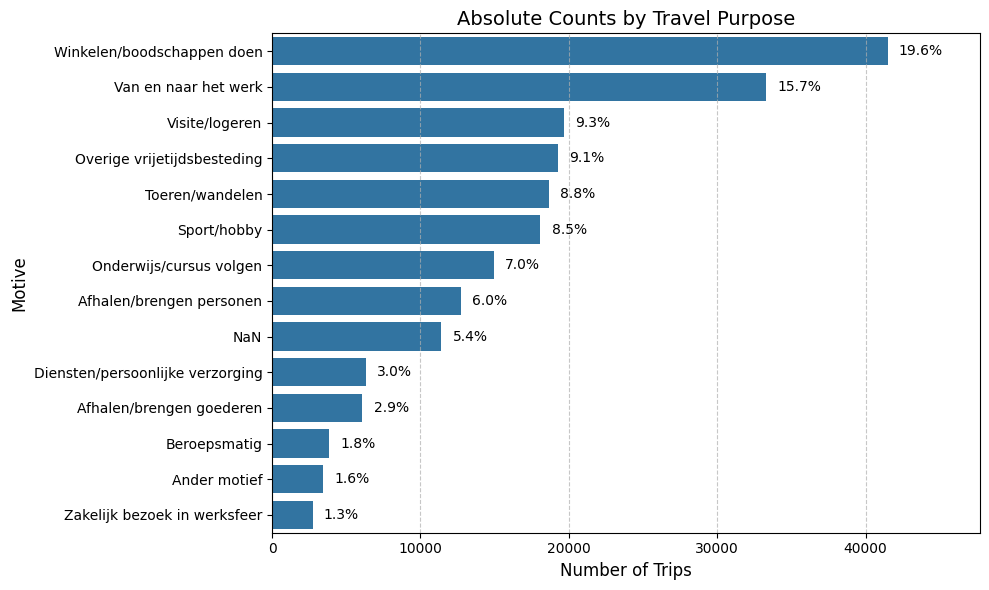

In [105]:
# Obtain Data
plot_motive = results["MotiefV"].sort_values('count', ascending=False)

# Def the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_motive, 
    x='count', 
    y='label'
)

# --- Add percentages to the right of each bar ---
for i, p in enumerate(ax.patches):
    # Get the percentage from your 'pct' column
    percentage = plot_motive['pct'].iloc[i]
    
    # Calculate position
    x_pos = p.get_width() # The end of the bar
    y_pos = p.get_y() + p.get_height() / 2 # The middle of the bar's thickness
    
    # Annotate
    ax.annotate(f'{percentage:.1f}%', 
                (x_pos, y_pos), 
                va='center', 
                ha='left', 
                xytext=(8, 0),             # Push text 8 points to the right
                textcoords='offset points',
                fontsize=10)

# Labels
plt.title('Absolute Counts by Travel Purpose', fontsize=14)
plt.xlabel('Number of Trips', fontsize=12)
plt.ylabel('Motive', fontsize=12)

# Increase x-limit to make room for the text labels
plt.xlim(0, plot_motive['count'].max() * 1.15)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Build Working Set from ODiN 2023
Expectedly, the most common motive for travelling was reported to be "Winkelen/boodschappen doen" which means "Shopping". The second most common motive which is also the purpose of our analysis was reported to be "Van en naar het werk". It is translated to English as "To and From Work" and it counts for nearly 16% of all reported trips. It is important to mention that "NaN" motives are also a significant part of the survey as 5.38% of the participants did not mention their trip purpose.

Before analyzing the dataset further we need to make a working version which contains only the relevant analytical variables. We are going to select 20 variables required to describe a commuting trip. Others are dropped to ease the work and avoid any confusion. To do so we are going to perform the below steps:
1. Select relevant columns from the dataset and rename them to English. (Source for Dutch Names: odin_metadata.csv) 
2. Map the original dutch column names to English names.
3. Drop the remaining variables from the working dataset.   

In [26]:
rename_map = {
    # Identifiers
    "OP" : "new_id", #0- no ; 1= yes
    "OPID" : "person_id",
    "VerplID" : "trip_id",
    "Verpl" : "new_trip_id", # 0 = no, 1 = new trip ; 6 = serries ; 7 = freight trip

    # Geography
    "WoGem" : "home_municipality",
    "VertGem" : "origin_municipality",
    "AankGem" : "dest_municipality",
    "VertPC" : "origin_postcode",
    "AankPC" : "dest_postcode",
    "BuurtAdam" : "amsterdam_neighborhood",

    # Trip characteristics
    "MotiefV" : "trip_purpose", # 1 = commuting ("Van en naar het werk")
    "Hvm" : "mode_detailed", # granular mode code
    "KHvm" : "mode_class", # 1 = car , 4 = PT, 5 = bike
    "HvmRol" : "mode_role", # 1=driver  2 =passenger
    "AantRit" : "n_legs", #number of legs - transfers in public transport
    "Maand" : "month",
    "Weekdag" : "weekday", # 2=Mon ... 6=Fri
    "Feestdag" : "is_holiday",
    "VertUur" : "departure_hour",
    "VertMin": "departure_minute",
    "Reisduur" : "travel_time_min",       # total door-to-door minutes
    "AfstV" : "distance_hm",           # trip distnace in hectometers — convert later imto km

    # Person characteristics
    "Leeftijd" : "age",
    "Geslacht" : "gender",                # 1=male, 2=female
    "HHBestInkG" : "income_decile",         # 1 (lowest) to 10 (highest)
    "OPRijbewijsAu" : "has_driving_license",   # 1=yes, 2=no
    "HHAuto" : "n_cars_household",

    # Survey weights
    "FactorV" : "weight_trip", #survey trip weight
    "FactorP" : "weight_person", #survey person weight
}

# Select and rename
work_data = odin_data[rename_map.keys()].rename(columns = rename_map).copy()

In [28]:
work_data.head(5)

,new_id,person_id,trip_id,new_trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,...,departure_minute,travel_time_min,distance_hm,age,gender,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person
0,1.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,363.0,1191,1105,0,...,20.0,20.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
1,0.0,2.700008e+11,2.700008e+13,1.0,437.0,363.0,437.0,1105,1191,0,...,0.0,15.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
2,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,0.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
3,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,45.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
4,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,0.0,30.0,10.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874


In [29]:
#convert distance in hectometers to km
hm_to_km = 0.1   # converting coefficient
work_data["distance_km"] = (work_data.distance_hm * hm_to_km).round(3)

In [37]:
# Count the number of trnasfers from the number of legs in a trip
# For non-PT modes, n_legs is always 1 (no legs), so transfers = 0
work_data["n_transfers"] = np.where(work_data.mode_class == maincode_pt, np.maximum(work_data.n_legs.fillna(1.0) - 1, 0),0).astype(np.int8)

# Transfer flag indicator for PT for trips with at least one transfer
work_data["has_transfer"] = (work_data["n_transfers"] > 0).astype(np.int8)

In [38]:
#Lets insert a flag when a trip was during peak hours
#AM peak: 07:00h - 09:00h ; 
#PM peak: 17:00h - 19:00h (selected based on the peak definition from Section 1.7)

# --- Peak hour definition ---
am_peak_start = 7
am_peak_end = 9
pm_peak_start = 17
pm_peak_end = 19

work_data["is_peak"] = (
    ((work_data.departure_hour.values >= am_peak_start) & (work_data.departure_hour.values < am_peak_end)) |
    ((work_data.departure_hour.values >= pm_peak_start) & (work_data.departure_hour.values < pm_peak_end))
).astype(np.int8)

In [112]:
work_data.departure_hour.values

array([ 8., 10., 12., ..., 20., 22., 13.], shape=(211991,))

In [39]:
# Maps KHvm codes to analytical labels used in all downstream steps
code_car_driver = 1.0
code_pt = 4.0
code_bike = 5.0

mode_label_map = {
    code_car_driver : "car",
    code_pt : "pt", #public transport
    code_bike : "bike",
}
work_data["chosen_mode"] = (work_data.mode_class.map(mode_label_map).astype("category"))

In [40]:
work_data.chosen_mode.value_counts().sort_values() #What mode is chosen the most by people between car, public transport and bike

chosen_mode
pt       9151
bike    50586
car     62674
Name: count, dtype: int64

In [41]:
print(f"Working sample shape: {work_data.shape}")
print(f"\nColumns retained ({len(work_data.columns)}):")
print(list(work_data.columns))
print(f"\nSample (5 rows):")
work_data.head(5)

Working sample shape: (211991, 34)

Columns retained (34):
['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality', 'origin_municipality', 'dest_municipality', 'origin_postcode', 'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose', 'mode_detailed', 'mode_class', 'mode_role', 'n_legs', 'month', 'weekday', 'is_holiday', 'departure_hour', 'departure_minute', 'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile', 'has_driving_license', 'n_cars_household', 'weight_trip', 'weight_person', 'distance_km', 'n_transfers', 'has_transfer', 'is_peak', 'chosen_mode']

Sample (5 rows):


,new_id,person_id,trip_id,new_trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,...,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person,distance_km,n_transfers,has_transfer,is_peak,chosen_mode
0,1.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,363.0,1191,1105,0,...,6.0,1.0,2.0,86521.379089,237.044874,3.6,0,0,1,car
1,0.0,2.700008e+11,2.700008e+13,1.0,437.0,363.0,437.0,1105,1191,0,...,6.0,1.0,2.0,86521.379089,237.044874,3.6,0,0,0,car
2,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,6.0,1.0,2.0,86521.379089,237.044874,0.1,0,0,0,NaN
3,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,6.0,1.0,2.0,86521.379089,237.044874,0.1,0,0,0,NaN
4,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,6.0,1.0,2.0,86521.379089,237.044874,1.0,0,0,0,NaN


## Dataset Filtering  and Scoping Down the Analysis

From the Codebook file in the repository we see that the origin ODiN file contains information on 7 different transport modes. Firstly, we will start by examine the distribution of those 7 transport modes for all Amsterdam commuters. From the Codebook we can see that the ODiN dataset contains two analytical variables for transport mode: 
1. `mode_detailed`- detailed transport mode (Hvm)
2. `mode_class`- transport mode class (KHvm)

Lets examine the trip distribution  based on these two variables. For the purpose, we are going to apply only the trip purpose and geography filters (commuting in Amsterdam).

In [42]:
weekday_codes_amst = [2.0, 3.0, 4.0, 5.0, 6.0]   # Monday to Friday
amsterdam_gem_code = 363 #Amsterdam area code
commute_code_amst = 1.0    # 1 = "Van en naar het werk" (commuting)

base_mask = (
    (work_data.home_municipality == amsterdam_gem_code) &
    (work_data.trip_purpose == commute_code_amst) &
    (work_data.weekday.isin(weekday_codes_amst)) &
    (work_data.is_holiday == 0)
    ) 

base_amst_data = work_data[base_mask].copy()
print(f"Amsterdam commuting trips (all modes): {len(base_amst_data):,}")

Amsterdam commuting trips (all modes): 1,389


In [43]:
base_amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'n_legs', 'month',
       'weekday', 'is_holiday', 'departure_hour', 'departure_minute',
       'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'distance_km', 'n_transfers', 'has_transfer',
       'is_peak', 'chosen_mode'],
      dtype='object')

In [89]:
# --- Detailed mode distribution (Hvm) ---
detailed_modes_codes = {
    1.0: "Car", 2.0: "Train", 3.0: "Bus", 4.0: "Tram",
    5.0: "Metro", 6.0: "Speedpedelec", 7.0: "E-bike",
    8.0: "Bicycle", 9.0: "Walking", 10.0: "Coach",
    11.0: "Van", 14.0: "Taxi", 16.0: "Motorcycle",
    17.0: "Moped (45km/h)", 18.0: "Moped (25km/h)"
}

dtl_mode_counts = base_amst_data.mode_detailed.value_counts().sort_index() # count trips per detailed transport mode class 
dtl_mode_pct    = (dtl_mode_counts / len(base_amst_data) * 100).round(1) #count the pct for each detailed transport mode class
dtl_mode_table  = pd.DataFrame({
    "Mode (Detailed)": dtl_mode_counts.index.map(lambda x: detailed_modes_codes.get(x, f"Other ({x})")),
    "Count": dtl_mode_counts.values,
    "Share(%)": dtl_mode_pct.values
})
print("=== Detailed transport mode — Amsterdam commuting ===")
print(dtl_mode_table.to_string(index=False))

print()

=== Detailed transport mode — Amsterdam commuting ===
Mode (Detailed)  Count  Share(%)
            Car    249      17.9
          Train    276      19.9
            Bus     71       5.1
           Tram     49       3.5
          Metro    172      12.4
         E-bike     76       5.5
        Bicycle    406      29.2
        Walking     58       4.2
            Van     10       0.7
     Motorcycle      3       0.2
 Moped (45km/h)     16       1.2
 Moped (25km/h)      1       0.1
   Other (22.0)      2       0.1



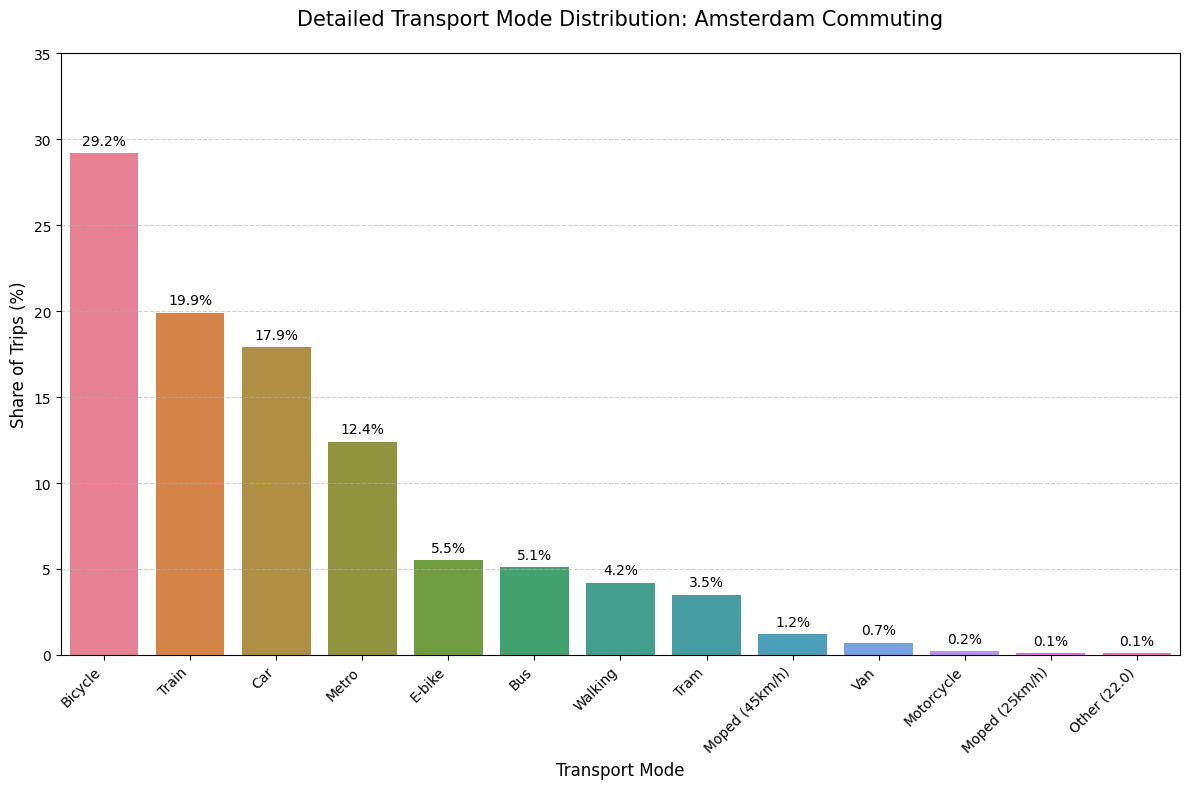

In [93]:
# --- Detailed mode distribution (Vertical) ---
plot_dtl = dtl_mode_table.sort_values("Share(%)", ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=plot_dtl,
    x="Mode (Detailed)",  # Categorical on X for vertical
    y="Share(%)",         # Numerical on Y for vertical
    hue="Mode (Detailed)",
    legend=False
)

# Add percentages on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.title('Detailed Transport Mode Distribution: Amsterdam Commuting', fontsize=15, pad=20)
plt.xlabel('Transport Mode', fontsize=12)
plt.ylabel('Share of Trips (%)', fontsize=12)

# 1. Increase height to prevent labels being cut off
plt.ylim(0, plot_dtl["Share(%)"].max() * 1.2) 

# 2. Rotate labels so they are readable
plt.xticks(rotation=45, ha='right')

# 3. Add horizontal gridlines for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [91]:
# --- Mode class distribution (KHvm) ---
modes_class_codes = {
    1.0: "Car - driver", 
    2.0: "Car - passenger", 
    3.0: "Train",
    4.0: "Bus/Tram/Metro (BTM)",
    5.0: "Bicycle",
    6.0: "Walking",
    7.0: "Other"
}

cls_mode_counts = base_amst_data.mode_class.value_counts().sort_index() # count trips per transport mode class 
cls_mode_pct    = (cls_mode_counts / len(base_amst_data) * 100).round(1) #count the pct for each transport mode class
cls_mode_table  = pd.DataFrame({
    "Mode Class": cls_mode_counts.index.map(lambda x: modes_class_codes.get(x, f"Other ({x})")),
    "Count": cls_mode_counts.values,
    "Share(%)": cls_mode_pct.values
})
print("=== Detailed transport mode — Amsterdam commuting ===")
print(cls_mode_table.to_string(index=False))

print()

=== Detailed transport mode — Amsterdam commuting ===
          Mode Class  Count  Share(%)
        Car - driver    218      15.7
     Car - passenger     31       2.2
               Train    276      19.9
Bus/Tram/Metro (BTM)    292      21.0
             Bicycle    482      34.7
             Walking     58       4.2
               Other     32       2.3



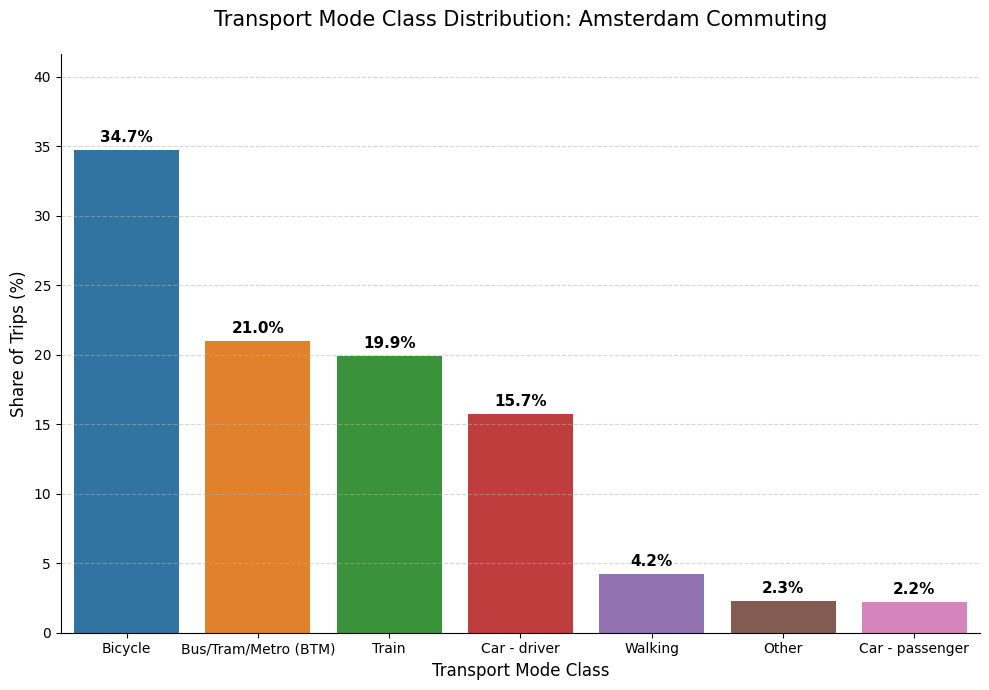

In [96]:
# Sort the data
plot_cls = cls_mode_table.sort_values("Share(%)", ascending=False)

plt.figure(figsize=(10, 7)) # Slightly narrower usually works better for fewer classes
ax = sns.barplot(
    data=plot_cls,
    x="Mode Class",     # Category on X
    y="Share(%)",       # Value on Y
    hue="Mode Class",
    legend=False
)

# Add percentages on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Labels and Title
plt.title('Transport Mode Class Distribution: Amsterdam Commuting', fontsize=15, pad=20)
plt.xlabel('Transport Mode Class', fontsize=12)
plt.ylabel('Share of Trips (%)', fontsize=12)

# Increase the Y-limit to make room for the labels at the top
plt.ylim(0, plot_cls["Share(%)"].max() * 1.2)

# Optional: Clean up the look
plt.xticks(rotation=0) # Only rotate if the class names are very long
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine() # Removes the top and right border for a cleaner look

plt.tight_layout()
plt.show()


From the two graphs above we can observe two important things. 

Firstly, within the `mode_class` = 4 class (bus/tram/metro), the detailed variable `mode_detailed`shows that bus (code 3), tram (code 4), and metro (code 5) are all present in the dataset. 

Secondly, the BTM modes (Bus/Tram/Metro) cannot be considered as independent alternatives due tothe following reasons:
1. CBS deliberately aggregates them into a single class in `mode_class` = 4 , reflecting their operational integration under a single fare system (GVB OV-chipkaart).
2. A commuter choosing "public transport" in Amsterdam selects an integrated network, not an individual vehicle type — the route taken on a given day may combine tram and metro legs.
3. Separating them would require trip-level assignment of stops to specific vehicle types, introducing a constructed variable with significant uncertainty. Therefore, for the purposes of this work we are going ot treat bus, tram, and metro as a single Public Transport (PT) alternative. This follows the practice of the CBS codebook itself and is consistent with the Amsterdam GVB network structure.

In [46]:
# Filter to BTM trips only (KHvm == 4)
btm_amst_data = base_amst_data[base_amst_data.mode_class == 4]

btm_detail = btm_amst_data.mode_detailed.value_counts().sort_index()
btm_pct = (btm_detail / len(btm_amst_data) * 100).round(1)

btm_table = pd.DataFrame({
    "Detailed mode": btm_detail.index.map(lambda x: detailed_modes_codes.get(x, f"Code {x}")),
    "Count": btm_detail.values,
    "Share within PT (%)": btm_pct.values
})

print("Composition of BTM code (Public Transport)")
print(f"Total BTM trips: {len(btm_amst_data):,}")
print()
print(btm_table.to_string(index=False))
print()
print("Decision: bus + tram + metro treated as one PT alternative.")

Composition of BTM code (Public Transport)
Total BTM trips: 292

Detailed mode  Count  Share within PT (%)
          Bus     71                 24.3
         Tram     49                 16.8
        Metro    172                 58.9

Decision: bus + tram + metro treated as one PT alternative.


## Tidy Data Construction
Now we need to filter the base dataset to get only the commuters' trips within the Amsterdam area.

In [47]:
amst_data = base_amst_data.copy() #create a copy of the base dataset

In [48]:
amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'n_legs', 'month',
       'weekday', 'is_holiday', 'departure_hour', 'departure_minute',
       'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile',
       'has_driving_license', 'n_cars_household', 'weight_trip',
       'weight_person', 'distance_km', 'n_transfers', 'has_transfer',
       'is_peak', 'chosen_mode'],
      dtype='object')

In [49]:
# Show all columns (none are hidden with "...")
pd.set_option('display.max_columns', None)

In [50]:
#Filter for regular trips only excluding trip series and freight (cargo) trips new_trip_id = 1 (Duthc name: Verpl)
amst_data = amst_data[amst_data.new_trip_id == 1]

In [51]:
#Filets for trips only in the Amsterdam are, working days and trip_purpose = commutin already applied in the base_mask for the base_amst_data daaset
#We need to filter the trips only for the desired transport mdoes: cars (1.0), public transport (4.0) and bikes (5.0)
keys_to_keep = [1.0, 4.0, 5.0]
choice_set = {k: modes_class_codes[k] for k in keys_to_keep}

amst_data = amst_data[amst_data.mode_class.isin(choice_set)] 

In [52]:
#We need to filter the trips where we have only the driver as a commuter as this is relevant for the mode choice
amst_data = amst_data[~((amst_data.mode_class == 1) & (amst_data.mode_role == 2))]


In [53]:
amst_data.shape

(768, 34)

In [54]:
amst_data.mode_class.value_counts().sort_index() # 

mode_class
1.0    210
4.0    116
5.0    442
Name: count, dtype: int64

In [115]:
amst_data["city"] = "Amsterdam"

## Data Cleaning

Before any transformations we are going to first check the missing values across all columns of the dataset. Each column with null values receives an explicit documented decision: drop row, impute or retain with a flag. 


In [55]:
amst_data.isna().sum()

new_id                    0
person_id                 0
trip_id                   0
new_trip_id               0
home_municipality         0
origin_municipality       0
dest_municipality         0
origin_postcode           0
dest_postcode             0
amsterdam_neighborhood    0
trip_purpose              0
mode_detailed             0
mode_class                0
mode_role                 0
n_legs                    0
month                     0
weekday                   0
is_holiday                0
departure_hour            0
departure_minute          0
travel_time_min           0
distance_hm               0
age                       0
gender                    0
income_decile             0
has_driving_license       0
n_cars_household          0
weight_trip               0
weight_person             0
distance_km               0
n_transfers               0
has_transfer              0
is_peak                   0
chosen_mode               0
dtype: int64

As we do not have null values we need to remove the records with codes = 'Unknown' for the key variables from the dataset.

In [56]:
cleaning_codes = {
    "income_decile" : (11.0, "Drop rows where == 11 (unknown code)"),
    "n_cars_household" : (10.0, "Drop rows where == 10 (unknown code)."),
    "has_driving_license" : (2.0,  "Drop rows where == 2 (unknown code)."),
}

n_cd = len(cleaning_codes)

coded_unknowns = pd.Series(
    {col: int((amst_data[col] == code).sum()) for col, (code, _) in cleaning_codes.items() if code is not None},
    name = "coded_unknowns"
)

print(coded_unknowns)

income_decile          61
n_cars_household        2
has_driving_license     0
Name: coded_unknowns, dtype: int64


We apply three filters above. We check for unkown codes for personal income, driving licence and number of cars in a household. 

First, we are going to remove the respondents with unknown income (coded as 11 in income_decile). Income is used as a segmentation variable in robustness checks — keeping the unknown values will create noise into income-dependent VoT estimates without adding usable information. Removing those records will affect a known share of the sample.

Then, we are going to apply numeric bounds to travel time and distance, removing values that are physically implausible for an Amsterdam urban commute.

In [57]:
amst_data = amst_data[amst_data.income_decile != 11.0]

In [58]:
amst_data = amst_data[amst_data.n_cars_household != 10.0]

In [59]:
amst_data.shape

(707, 34)

Now we are going to remove the trips with unrealistic travel times. For the purposes of this analysis we consider "unrealistic" a trip that lasted less than 2 mins and more than 120 mins (2 hours). 

In [60]:
amst_data = amst_data[
    (amst_data.travel_time_min >= min_trip_dur) &
    (amst_data.travel_time_min <= max_trip_dur)
    ]

In [61]:
amst_data.shape

(704, 34)

We are going to remove as well the trips with unrealistic travelled distance. We consider "unrealistc" all trips with a distance less than 0.2km and more than 50km 

In [62]:
amst_data = amst_data[
    (amst_data.distance_km >= min_trip_distance) &
    (amst_data.distance_km <= max_trip_distance)
    ]

In [63]:
amst_data.shape

(681, 34)

In [64]:
mode_counts = amst_data.chosen_mode.value_counts().sort_index()

In [65]:
mode_counts

chosen_mode
bike    407
car     180
pt       94
Name: count, dtype: int64

In [ ]:
# Bin Amsterdam raw age (Leeftijd) into NTS Age_B04ID 9-band scheme
# Must run BEFORE merging Amsterdam + London
amst_data["age_band"] = pd.cut(amst_data.age,bins = age_bins, labels = age_labels, right = False).astype(int)

# Collapse Amsterdam income deciles → quintiles
amst_data["income_quintile"] = amst_data.income_decile.map(decile_to_quintile)

### Distribution Inspection and Outlier Report
We are going to inspect now the distributions of the three continuous variables that we will use in the MNL utility function: travel time, trip distance, and income decile. Distributions are shown per mode using weighted counts (weight_trip) to reflect the survey design. Outliers are identified using the IQR method and reported — but not automatically removed. We are going to distinguish between wrong entries (already removed above) and unusual realities (retained and noted).

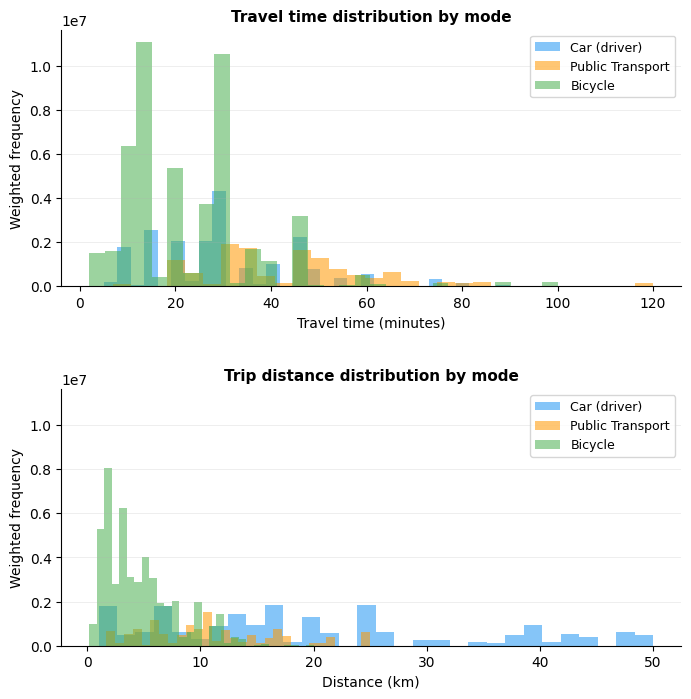

In [66]:
variables  = ["travel_time_min", "distance_km"]
mode_colors = {"car": "#2196F3", "pt": "#FF9800", "bike": "#4CAF50"}
transport_modes = ["car", "pt", "bike"]
mode_labels = {"car": "Car (driver)", "pt": "Public Transport", "bike": "Bicycle"}

fig, axes = plt.subplots(2,1, figsize = (8, 8),sharex = False ,sharey = True)

for ax, var in zip(axes, variables):
    for mode in transport_modes:
        subset = amst_data[amst_data.chosen_mode == mode]
        # Weighted histogram using survey weights
        ax.hist(
            subset[var],
            weights = subset.weight_trip,
            bins = 30,
            alpha = 0.55,
            color = mode_colors[mode],
            label = mode_labels[mode],
            edgecolor = "none"
        )
    ax.set_xlabel("Travel time (minutes)" if var == "travel_time_min" else "Distance (km)", fontsize=10)
    ax.set_ylabel("Weighted frequency", fontsize = 10)
    ax.set_title("Travel time distribution by mode" if var == "travel_time_min" else "Trip distance distribution by mode",
                 fontsize = 11, fontweight = "bold")
    ax.legend(fontsize = 9)
    ax.grid(axis = "y", alpha = 0.3, linewidth = 0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(hspace = 0.4)
# plt.tight_layout()
# plt.savefig("data/raw/odin/path", dpi=150, bbox_inches="tight")
plt.show()


The above distributions shows the modal preferences based on travel time and trip distnace. 

Looking at the Travel Time graph bicycles are the primary choice for short-duration trips, specifically those under 30 minutes. Frequency peaks at two time durations at 15 minutes and 30 minutes. On the other hand, car usage is most concentrated around the 30-minute mark. Public Transit (PT) has an interesting pattern as there is no distinct peak for PT chose, but there is a stable distribution for trips lasting between 30 and 50 minutes. We can suggest that PT is a preferred mode for mid-to-long duration commutes.

On the trip distance distribution graph bicycles seems to dominate the short-distance travel under 10 km. However, over the 10 km threshold, bike usage drops significantly as PT and car frequencies rise. Public Transit reaches its peak utility at approximately 10 km, with declining usage for shorter or longer distances. Car travel maintains a steady frequency for distances up to 30 km and seems as the exclusive mode choice for all trips exceeding 25 km.


It is interesting to see what is the spread of the values of our three variables and if there are outliers. We are going to measure the spread of the middle 50% of our amst_data set. To do that we need to  find the quantiles Q1(25th percentile) and Q3(75th percentile) of our chosen_mode variable. We are going to calculate the Interquartile Range (IQR) which is where 50% of our data is distributed by applying the formula IQR = Q3 - Q1. 

To decide what is too far from the middle we need to set the "fences" (boundaries): 
1. Lower Fence = $Q1 - (1.5 * IQR)$
2. Upper Fence = $Q3 + (1.5 * IQR)$

Why 1.5? This a heuristic established by John Tukey. In a perfectly normal distribution, 1.5 IQRs covers about 99.3% of the data, making anything outside that range statistically rare.

In [67]:
# 1. Melt the data so variables are in a single column for grouping
amst_melted = amst_data.melt(id_vars = ['chosen_mode'], value_vars = variables)

In [68]:
amst_melted.head(5)

,chosen_mode,variable,value
0,pt,travel_time_min,50.0
1,pt,travel_time_min,45.0
2,car,travel_time_min,20.0
3,car,travel_time_min,25.0
4,pt,travel_time_min,35.0


In [69]:
# 2. Calculate Q1 and Q3 per group
amst_stats = amst_melted.groupby(['variable', 'chosen_mode'],observed = False).value.quantile([0.25, 0.75]).unstack()
amst_stats.columns = ['Q1', 'Q3']

In [70]:
amst_stats.head(5)

Q1     Q3
variable        chosen_mode               
distance_km     bike          2.000   6.60
                car           8.950  29.25
                pt            6.275  14.15
travel_time_min bike         15.000  30.00
                car          20.000  40.00

In [72]:
# 3. Define the upper and lower boundaries (fences)
amst_stats['iqr'] = amst_stats.Q3 - amst_stats.Q1 
amst_stats['lower'] = amst_stats.Q3 - 1.5 * amst_stats.iqr
amst_stats['upper'] = amst_stats.Q3 + 1.5 * amst_stats.iqr

In [73]:
# 4. Count outliers by merging stats back to the melted data
amst_merged = amst_melted.merge(amst_stats, on = ['variable', 'chosen_mode'])
amst_merged['is_outlier'] = (amst_merged.value < amst_merged.lower) | (amst_merged.value > amst_merged.upper)
n_outliers = amst_merged.groupby(['variable', 'chosen_mode'], observed = False).is_outlier.sum().reset_index()

In [74]:
amst_merged.head(10)

,chosen_mode,variable,value,Q1,Q3,iqr,lower,upper,is_outlier
0,pt,travel_time_min,50.0,30.0,53.0,23.0,18.5,87.5,False
1,pt,travel_time_min,45.0,30.0,53.0,23.0,18.5,87.5,False
2,car,travel_time_min,20.0,20.0,40.0,20.0,10.0,70.0,False
3,car,travel_time_min,25.0,20.0,40.0,20.0,10.0,70.0,False
4,pt,travel_time_min,35.0,30.0,53.0,23.0,18.5,87.5,False
5,bike,travel_time_min,15.0,15.0,30.0,15.0,7.5,52.5,False
6,bike,travel_time_min,30.0,15.0,30.0,15.0,7.5,52.5,False
7,bike,travel_time_min,25.0,15.0,30.0,15.0,7.5,52.5,False
8,bike,travel_time_min,20.0,15.0,30.0,15.0,7.5,52.5,False
9,bike,travel_time_min,30.0,15.0,30.0,15.0,7.5,52.5,False


In [75]:
n_outliers

,variable,chosen_mode,is_outlier
0,distance_km,bike,8
1,distance_km,car,0
2,distance_km,pt,4
3,travel_time_min,bike,31
4,travel_time_min,car,8
5,travel_time_min,pt,2


In [76]:
# 5. Build final report
amst_report = amst_stats.reset_index().merge(n_outliers, on = ['variable', 'chosen_mode'])
amst_report['mode'] = amst_report.chosen_mode.map(mode_labels)

In [77]:
amst_report

,variable,chosen_mode,Q1,Q3,iqr,lower,upper,is_outlier,mode
0,distance_km,bike,2.000,6.60,4.600,-0.3000,13.5000,8,Bicycle
1,distance_km,car,8.950,29.25,20.300,-1.2000,59.7000,0,Car (driver)
2,distance_km,pt,6.275,14.15,7.875,2.3375,25.9625,4,Public Transport
3,travel_time_min,bike,15.000,30.00,15.000,7.5000,52.5000,31,Bicycle
4,travel_time_min,car,20.000,40.00,20.000,10.0000,70.0000,8,Car (driver)
5,travel_time_min,pt,30.000,53.00,23.000,18.5000,87.5000,2,Public Transport


The lower fences for bike and car on variable = distance_km have negative values which can not be real. Hence, we can consider the lower fence as 0.   

The bycicle is the most frequent choice in our dataset and with the highest amount of outliers as well. Expectedly the distance upper fence is much lower compared to the other transport. Even though, the most frequent trips are between 2 adn 6.6kms there are still enthusiasts who choose the bike for long trips longer than 13.0km (our lower fence is 0 so all our outliers are above the upper boundary).           

The dataset suggests that the upper boundary for bike trip duration is 52.5 minutes. As the Netherlands is a bike friendly country we can assume that there are group of "long-distance commuters" who prefer the bike regardless of the long duration trip. Even though a 60-mins bike it trip is physically possible, it can be statistically flagged.     

The car data appears to be "clean" with 0 distance outliers and 8 travel time outliers. This suggests that the car choice frequency in our dataset follow a "normal" distribution. The big IQR = 20.3km for cars suggest that commuters choose car for trips with varying lengths, but they rarely cross into "extreme" distnaces (> 59.7km). This is actually expected as 60km is actually outside of Amsterdam municipality area.

The car data on travel_time_min appears to have significnatly more outliers - 8 suggesting commuters being stuck in traffic. The IQR is again relatively big equalst to 20mins indicating commuters prefer the car choice from short to mid-long trips. 

Public Transport seems to be the most "stable" choice amonth all. It has the tightest distribution of of IQR = 23 mins and 8kms. We also observe a low number of outliers (only 2) which can be considered as expected as bus/train/metro operates on a fixed schedule and routes. This limits how much travel  time and distance can vary compared to the degrees of freedom for the other two choices.  



## Final Validation and Export
In this step we are going to validate the analytical sample against the minimum requirements for MNL estimation (add source for "Problem Formulation"). We are going to save and export the last prepared version of our dataset.  


In [78]:
mode_counts = amst_data.chosen_mode.value_counts() #Check if all modes are chosen > 50 times (Treshold for the MNL model)

In [79]:
mode_counts

chosen_mode
bike    407
car     180
pt       94
Name: count, dtype: int64

In [80]:
# 1. Group by mode and calculate both metrics at once
stats = amst_data.groupby("chosen_mode",observed = False).weight_trip.agg(["count", "sum"])

# 2. Vectorized calculation of percentages for the whole table
total_count = len(amst_data)
total_weight = amst_data.weight_trip.sum()

stats["unwt_pct"] = (stats['count'] / total_count) * 100
stats["wt_pct"]   = (stats['sum'] / total_weight) * 100

#Save the results per transport mode
results_dict = {
    mode_labels[mode]: [row['unwt_pct'], row['wt_pct']] for mode, row in stats.iterrows()
}

report_pct = pd.DataFrame.from_dict(
    results_dict, 
    orient = 'index', 
    columns = ['Unweighted Score %', 'Weighted Score %']
)

In [81]:
report_pct

,Unweighted Score %,Weighted Score %
Bicycle,59.765051,60.09670
Car (driver),26.431718,24.44721
Public Transport,13.803231,15.45609


Who benefits from the weights? PT and Bikes shares increase their choice while cars' share is reduced by 2%. 
   

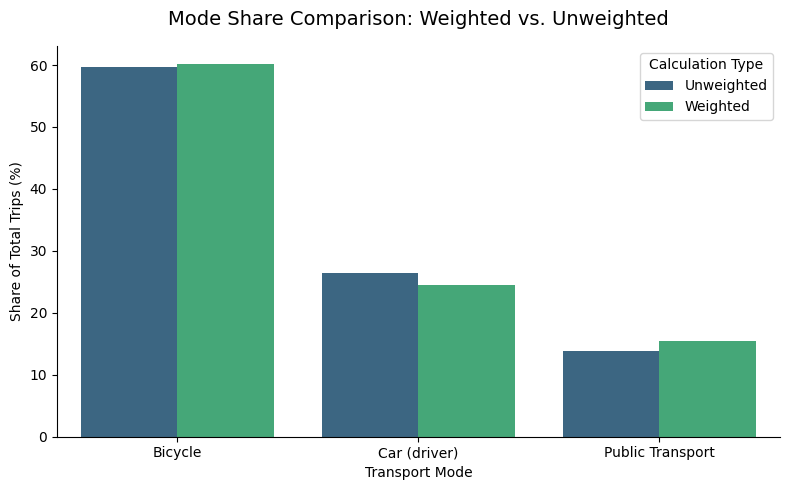

In [82]:
# 1. Map the labels and select only the percentage columns
plot_pct = stats[['unwt_pct', 'wt_pct']].copy()
plot_pct.index = plot_pct.index.map(mode_labels)
plot_pct.index.name = 'Transport Mode'

# 2. Reshape (melt) the data for side-by-side plotting
plot_pct = plot_pct.reset_index().melt(id_vars = 'Transport Mode', var_name= 'Type', value_name='Share (%)')
plot_pct['Type'] = plot_pct['Type'].map({'unwt_pct': 'Unweighted', 'wt_pct': 'Weighted'})


plt.figure(figsize=(8, 5))
sns.barplot(data = plot_pct, x = 'Transport Mode', y = 'Share (%)', hue = 'Type', palette='viridis')


plt.title('Mode Share Comparison: Weighted vs. Unweighted', fontsize= 14, pad = 15)
plt.ylabel('Share of Total Trips (%)')
# plt.xlabel('')
plt.legend(title = 'Calculation Type')
sns.despine()

plt.tight_layout()
plt.show()

In [126]:
# Bin Amsterdam raw age (Leeftijd) into NTS Age_B04ID 9-band scheme
# Must run BEFORE merging Amsterdam + London
amst_data["age_band"] = pd.cut(amst_data.age, bins = age_bins, labels = age_labels, right = False).astype(int)

# Collapse Amsterdam income deciles → quintiles
amst_data["income_quintile"] = amst_data.income_decile.map(decile_to_quintile)

In [132]:
# --- Export ---
amst_data.to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\processed\amst_processed.csv", index=False)
print(f"\n Processed dataset saved to data\processed")


 Processed dataset saved to data\processed


Right now we have amst_processed — it tells us who chose which mode, their socioeconomics, and the travel time and distance of their chosen mode only. That is not enough for the MNL model. The model requires attributes for all three alternatives for every trip, including the modes the person did not take.